# Music Recommendor Algorithm
### Collaborators: Aisha Mardini, Lilly Peters, Shinung Li

## First dataset:
- https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset
- Used for content based filtering

\
___Elements___

- **track_id:** The Spotify ID for the song
- **artists:** The artists' names. If there is more than one artist, they are separated by a ;
- **album_name:** The album name
- **track_name:** Name of the track
- **popularity:** The popularity is calculated by Spotify's algorithm from [0,100]. Based on the total number of plays the track has had and how recent those plays are. 
- **duration_ms:** The song length in milliseconds
- **explicit:** Whether or not the song has explicit lyrics (true = yes; false = no OR unknown)
- **danceability:** How suitable a track is for dancing from [0,1] based on a combination of elements including tempo, rhythm stability, beat strength, and overall regularity. 
- **energy:** Represents a perceptual measure of intensity and activity from [0,1]. Typically, energetic tracks feel fast, loud, and noisy. 
- **key:** The key the track is in mapped using standard Pitch Class notation. E.g. 0 = C, 1 = C♯/D♭, 2 = D, and so on. If no key was detected, the value is -1
- **loudness:** How loud the track is in decibels
- **mode:** Mode indicates the modality (major or minor) of a trackMajor is represented by 1 and minor is 0
- **speechiness:** Speechiness detects the presence of spoken words in a track from [0,1]
- **acousticness:** Whether the track is acoustic from [0,1]. 1.0 represents high confidence the track is acoustic
- **instrumentalness:** Predicts whether a track contains no vocals from [0,1]
- **liveness:** Detects the presence of an audience in the recording from [0,1]
- **valence:** Musical positiveness conveyed by a track from [0,1]. Tracks with high valence sound more positive (e.g. happy, cheerful, euphoric), while tracks with low valence sound more negative (e.g. sad, depressed, angry)
- **tempo:** Estimated tempo of a track in beats per minute (BPM). 
- **time_signature:** An estimated time signature. The time signature (meter) is a notational convention to specify how many beats are in each bar (or measure). The time signature ranges from 3 to 7 indicating time signatures of 3/4, to 7/4.
- **track_genre:** The genre of the song

## Step 1:
- Upload the data
- Data cleaning and preprocessing

In [28]:
# import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import NMF
import random

# Loading in Spotify datasets
df_read = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/dataset.csv') # MUST DOWNLOAD LOCALLY AND CHANGE PATH
df_read.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [30]:
# checking if there are NaN values in track id, artists, albums
df_read[df_read["track_id"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre


In [32]:
df_read[df_read["artists"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [34]:
df_read[df_read["album_name"].isna()]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
65900,65900,1kR4gIb7nGxHPI3D2ifs59,NaN,NaN,NaN,0,0,False,0.501,0.583,...,-9.46,0,0.0605,0.69,0.00396,0.0747,0.734,138.391,4,k-pop


In [36]:
# drop nan values
df_read = df_read.dropna()

In [38]:
# check to see if any rows are duplicates and drop them
#print(df_read.drop_duplicates().any())
df_read = df_read.drop_duplicates()

In [40]:
# checking the types for columns
df_read.dtypes

Unnamed: 0            int64
track_id             object
artists              object
album_name           object
track_name           object
popularity            int64
duration_ms           int64
explicit               bool
danceability        float64
energy              float64
key                   int64
loudness            float64
mode                  int64
speechiness         float64
acousticness        float64
instrumentalness    float64
liveness            float64
valence             float64
tempo               float64
time_signature        int64
track_genre          object
dtype: object

In [42]:
# drop the unnamed column
df = df_read.drop(columns=['Unnamed: 0'])

In [44]:
# check column names
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

In [46]:
# check statistics
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [48]:
# check to see if multiartists are separated by semicolon
df[df["artists"].str.contains(";")]["artists"].unique()[:20]

array(['Ingrid Michaelson;ZAYN', 'A Great Big World;Christina Aguilera',
       'Jason Mraz;Colbie Caillat', 'Chord Overstreet;Deepend',
       'Andrew Foy;Renee Foy', 'Boyce Avenue;Bea Miller',
       'Boyce Avenue;Jennel Garcia', 'Brandi Carlile;Sam Smith',
       'Brandi Carlile;Lucius', 'Eddie Vedder;Nusrat Fateh Ali Khan',
       'Boyce Avenue;Fifth Harmony', 'Gabrielle Aplin;JP Cooper',
       'Ray LaMontagne;Sierra Ferrell', 'Susie Suh;Robot Koch',
       'Tyler Ward;Lindsey Stirling;Kina Grannis', 'Eden Elf;Ren Avel',
       'Boyce Avenue;Rachel Grae', 'Zack Tabudlo;Yonnyboii',
       'Tyler Ward;Karis;Ray Lorraine', 'Agustín Amigó;Nylonwings'],
      dtype=object)

In [50]:
# how many loudness columns are 0
(df["loudness"] == 0).sum()

np.int64(0)

In [52]:
# how many instrumentalness columns are 0
(df["instrumentalness"] == 0).sum()

np.int64(38763)

In [54]:
# how many tempo columns are 0
(df["tempo"] == 0).sum()

np.int64(157)

In [56]:
# drop temp columns that are 0
df = df[df["tempo"] != 0]

In [58]:
# remove artist's duplicated songs
df = df.sort_values("popularity", ascending=False).drop_duplicates(subset=["track_name", "artists"], keep="first")

In [60]:
# check to see dropped
df.duplicated(subset=["track_name", "artists"]).sum()

np.int64(0)

In [62]:
# remove songs with popularity == 0
df = df[df["popularity"] > 0]

In [64]:
# check statistics again
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,76444.000000,7.644400e+04,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000,76444.000000
mean,37.437732,2.315885e+05,0.562729,0.641205,5.287269,-8.470715,0.633248,0.089821,0.322443,0.182218,0.220964,0.466495,122.644597,3.907462
std,17.848746,1.152993e+05,0.174637,0.254297,3.557360,5.139490,0.481921,0.118464,0.335078,0.329580,0.199582,0.261876,29.640805,0.418265
min,1.000000,2.426600e+04,0.051300,0.000020,0.000000,-46.591000,0.000000,0.022100,0.000000,0.000000,0.009250,0.000000,30.322000,0.000000
25%,23.000000,1.741060e+05,0.451000,0.465000,2.000000,-10.304250,0.000000,0.036100,0.014900,0.000000,0.098700,0.247000,99.952000,4.000000
50%,37.000000,2.157745e+05,0.576000,0.682000,5.000000,-7.224000,1.000000,0.049300,0.184000,0.000083,0.133000,0.452000,122.521500,4.000000
75%,50.000000,2.679060e+05,0.691000,0.859000,8.000000,-5.127000,1.000000,0.087700,0.613000,0.140000,0.285000,0.678000,140.815500,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 2nd Dataset
\
Second Dataset:
- https://www.kaggle.com/competitions/kkbox-music-recommendation-challenge/data
- Download: train.csv, songs.csv, members.csv, and song_extra_info.csv
- Used for collaborative filtering

In [71]:
# load in all 2nd datasets; view columns
# DOWNLOAD ALL LOCALLY AND CHANGE PATHS
train = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/train.csv')
songs = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/songs.csv')
members = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/members.csv')
song_extra = pd.read_csv('/Users/aishamardini/Downloads/PIC16B/song_extra_info.csv')

In [72]:
# print info of all datasets
datasets = [train, songs, members, song_extra]
d = ["train", "songs", "members", "song_extra_info"]

for i, ds in enumerate(datasets):
    print(d[i] + ".csv information:")
    print("Column names: ", ds.columns)
    print("Number of duplicates: ", ds.duplicated().sum())
    print("Number of null in columns: \n", ds.isnull().sum())
    print()

train.csv information:
Column names:  Index(['msno', 'song_id', 'source_system_tab', 'source_screen_name',
       'source_type', 'target'],
      dtype='object')
Number of duplicates:  0
Number of null in columns: 
 msno                       0
song_id                    0
source_system_tab      24849
source_screen_name    414804
source_type            21539
target                     0
dtype: int64

songs.csv information:
Column names:  Index(['song_id', 'song_length', 'genre_ids', 'artist_name', 'composer',
       'lyricist', 'language'],
      dtype='object')
Number of duplicates:  0
Number of null in columns: 
 song_id              0
song_length          0
genre_ids        94116
artist_name          0
composer       1071358
lyricist       1945306
language             1
dtype: int64

members.csv information:
Column names:  Index(['msno', 'city', 'bd', 'gender', 'registered_via',
       'registration_init_time', 'expiration_date'],
      dtype='object')
Number of duplicates:  0
Numbe

In [73]:
# select columns for main dataset
train = train[['msno', 'song_id', 'source_system_tab', 'source_type', 'target']]
print("Number of appreances: ", train['source_system_tab'].value_counts())
train = train[~train['source_system_tab'].isin(['notification', 'settings'])]

Number of appreances:  source_system_tab
my library      3684730
discover        2179252
search           623286
radio            476701
listen with      212266
explore          167949
notification       6185
settings           2200
Name: count, dtype: int64


In [74]:
# print data
train

,msno,song_id,source_system_tab,source_type,target
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,online-playlist,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,local-playlist,1
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,local-playlist,1
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,local-playlist,1
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,online-playlist,1
...,...,...,...,...,...
7377413,6xdFzPlrasIDD95mQWXVC3Bg4ptnGYtBl4ztVEZMddU=,VJTxizih/o28kXCbtPbIyWXScoXGvxyYtl6R+0YB5JM=,my library,local-playlist,1
7377414,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,z1mqaU9YOX7T/PFDvUoWozdFq7rC3KwaQP7nFVprjMI=,search,song,0
7377415,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,750RprmFfLV0bymtDH88g24pLZGVi5VpBAI300P6UOA=,search,song,1
7377416,0aH4Hd3ziPSRHClRX8rkeOEaAG5EPPkW1mKGCdXEok0=,G8wgqObgeAMER/rVCIlgcNeQ8mm0CzF/GsxiMK8TTnA=,discover,online-playlist,1


In [75]:
# 2nd dataset drop NAN
members = members[['bd', 'msno', 'city']]
members.dropna()

,bd,msno,city
0,0,XQxgAYj3klVKjR3oxPPXYYFp4soD4TuBghkhMTD4oTw=,1
1,0,UizsfmJb9mV54qE9hCYyU07Va97c0lCRLEQX3ae+ztM=,1
2,0,D8nEhsIOBSoE6VthTaqDX8U6lqjJ7dLdr72mOyLya2A=,1
3,0,mCuD+tZ1hERA/o5GPqk38e041J8ZsBaLcu7nGoIIvhI=,1
4,0,q4HRBfVSssAFS9iRfxWrohxuk9kCYMKjHOEagUMV6rQ=,1
...,...,...,...
34398,0,Wwd/cudKVuLJ3txRVxlg2Zaeliu+LRUfiBmfrnxhRCY=,1
34399,18,g3JGnJX6Hg50lFbrNWfsHwCUmApIkiv2M8sXOaeXoIQ=,4
34400,0,IMaPMJuyN+ip9Vqi+z2XuXbFAP2kbHr+EvvCNkFfj+o=,1
34401,0,WAnCAJjUty9Stv8yKtV7ZC7PN+ilOy5FX3aIJgGPANM=,1


In [76]:
# FIRST MERGE: add a song name column by merging the 2 datasets based on song id

merged_song = pd.merge(songs, song_extra[['song_id', 'name']], on='song_id', how='left')
merged_song = merged_song.drop_duplicates()
merged_song.dropna()
# cut unneeded columns
merged_song = merged_song[['artist_name', 'name', 'song_id']]

In [77]:
print("1st Merged Dataset (Song Names and ID):")
merged_song

1st Merged Dataset (Song Names and ID):


,artist_name,name,song_id
0,張信哲 (Jeff Chang),焚情,CXoTN1eb7AI+DntdU1vbcwGRV4SCIDxZu+YD8JP8r4E=
1,BLACKPINK,PLAYING WITH FIRE,o0kFgae9QtnYgRkVPqLJwa05zIhRlUjfF7O1tDw0ZDU=
2,SUPER JUNIOR,SORRY| SORRY,DwVvVurfpuz+XPuFvucclVQEyPqcpUkHR0ne1RQzPs0=
3,S.H.E,愛我的資格,dKMBWoZyScdxSkihKG+Vf47nc18N9q4m58+b4e7dSSE=
4,貴族精選,Mary Had a Little Lamb,W3bqWd3T+VeHFzHAUfARgW9AvVRaF4N5Yzm4Mr6Eo/o=
...,...,...,...
2296315,Catherine Collard,Schumann: Papillons| Op. 2: II. Prestissimo,lg6rn7eV/ZNg0+P+x77kHUL7GDMfoL4eMtXxncseLNA=
2296316,紀文惠 (Justine Chi),怎麼啦,nXi1lrSJe+gLoTTNky7If0mNPrIyCQCLwagwR6XopGU=
2296317,Various Artists,Still Here,9KxSvIjbJyJzfEVWnkMbgR6dyn6d54ot0N5FKyKqii8=
2296318,Peter Paul & Mary,If I Had My Way,UO8Y2MR2sjOn2q/Tp8/lzZTGKmLEvwZ20oWanG4XnYc=


In [78]:
# check if theres any duplicates
print("How many duplicated songs in dataset: ", merged_song.duplicated().sum())

How many duplicated songs in dataset:  0


In [79]:
# SECOND merging 
colab_df = pd.merge(train, merged_song[['song_id', 'name', 'artist_name']], on='song_id', how='left')
colab_df

,msno,song_id,source_system_tab,source_type,target,name,artist_name
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,explore,online-playlist,1,Good Grief,Bastille
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,my library,local-playlist,1,Lords of Cardboard,Various Artists
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,my library,local-playlist,1,Hip Hop Is Dead(Album Version (Edited)),Nas
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,my library,local-playlist,1,Disco Africa,Soundway
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,explore,online-playlist,1,Sleep Without You,Brett Young
...,...,...,...,...,...,...,...
7369028,6xdFzPlrasIDD95mQWXVC3Bg4ptnGYtBl4ztVEZMddU=,VJTxizih/o28kXCbtPbIyWXScoXGvxyYtl6R+0YB5JM=,my library,local-playlist,1,Still D.R.E.,Dr. Dre
7369029,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,z1mqaU9YOX7T/PFDvUoWozdFq7rC3KwaQP7nFVprjMI=,search,song,0,Locked Away,R. City feat. Adam Levine
7369030,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,750RprmFfLV0bymtDH88g24pLZGVi5VpBAI300P6UOA=,search,song,1,FLY OUT,兄弟本色G.U.T.S. (姚中仁、張震嶽、頑童MJ116)
7369031,0aH4Hd3ziPSRHClRX8rkeOEaAG5EPPkW1mKGCdXEok0=,G8wgqObgeAMER/rVCIlgcNeQ8mm0CzF/GsxiMK8TTnA=,discover,online-playlist,1,Wonderwall,Brad Mehldau Trio


In [80]:
# FINAL merged and clean dataset
collab = pd.merge(colab_df, members[['bd', 'msno', 'city']], on='msno', how='left')

# rename columns to be more explicit
collab = collab.rename(columns={'bd': 'age', 'msno':'user', 'target':'repeated'})

# source_system_tab sees where the song was found (either in the playlist, search, discover, explore, radio, or listened with someone)
collab = collab.dropna(subset=['source_system_tab'])

print("Unique outputs in source_system_tab ", collab['source_system_tab'].unique())


Unique outputs in source_system_tab  ['explore' 'my library' 'search' 'discover' 'radio' 'listen with']


In [89]:
# encode source system tab column 1-6
# strongest signal to weakest
collab['source_system_tab'] = collab['source_system_tab'].map(
    {
    'my library': 6, 
    'search': 5, 
    'discover': 4,      
    'explore': 3, 
    'radio': 2,
    'listen with': 1 
    })


In [91]:
# view distribution of values
collab['source_system_tab'].unique()
collab['source_system_tab'].value_counts()

source_system_tab
6    3684730
4    2179252
5     623286
2     476701
1     212266
3     167949
Name: count, dtype: int64

In [92]:
print("FINAL Merged Dataset:")
collab

FINAL Merged Dataset:


,user,song_id,source_system_tab,source_type,repeated,name,artist_name,age,city
0,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,BBzumQNXUHKdEBOB7mAJuzok+IJA1c2Ryg/yzTF6tik=,3,online-playlist,1,Good Grief,Bastille,0,1
1,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,bhp/MpSNoqoxOIB+/l8WPqu6jldth4DIpCm3ayXnJqM=,6,local-playlist,1,Lords of Cardboard,Various Artists,24,13
2,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,JNWfrrC7zNN7BdMpsISKa4Mw+xVJYNnxXh3/Epw7QgY=,6,local-playlist,1,Hip Hop Is Dead(Album Version (Edited)),Nas,24,13
3,Xumu+NIjS6QYVxDS4/t3SawvJ7viT9hPKXmf0RtLNx8=,2A87tzfnJTSWqD7gIZHisolhe4DMdzkbd6LzO1KHjNs=,6,local-playlist,1,Disco Africa,Soundway,24,13
4,FGtllVqz18RPiwJj/edr2gV78zirAiY/9SmYvia+kCg=,3qm6XTZ6MOCU11x8FIVbAGH5l5uMkT3/ZalWG1oo2Gc=,3,online-playlist,1,Sleep Without You,Brett Young,0,1
...,...,...,...,...,...,...,...,...,...
7369028,6xdFzPlrasIDD95mQWXVC3Bg4ptnGYtBl4ztVEZMddU=,VJTxizih/o28kXCbtPbIyWXScoXGvxyYtl6R+0YB5JM=,6,local-playlist,1,Still D.R.E.,Dr. Dre,26,4
7369029,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,z1mqaU9YOX7T/PFDvUoWozdFq7rC3KwaQP7nFVprjMI=,5,song,0,Locked Away,R. City feat. Adam Levine,0,1
7369030,ZxbVmt3Kh/XOH+h58c2Kdj6SjFZk+wnUO006IgWzMQE=,750RprmFfLV0bymtDH88g24pLZGVi5VpBAI300P6UOA=,5,song,1,FLY OUT,兄弟本色G.U.T.S. (姚中仁、張震嶽、頑童MJ116),0,1
7369031,0aH4Hd3ziPSRHClRX8rkeOEaAG5EPPkW1mKGCdXEok0=,G8wgqObgeAMER/rVCIlgcNeQ8mm0CzF/GsxiMK8TTnA=,4,online-playlist,1,Wonderwall,Brad Mehldau Trio,0,5


In [93]:
# column names for final dataset
collab.columns

Index(['user', 'song_id', 'source_system_tab', 'source_type', 'repeated',
       'name', 'artist_name', 'age', 'city'],
      dtype='object')

# EXTRA CLEANING

In [95]:
# cleaning data further

collab = collab[(collab['age'] > 0) & (collab['age'] < 100)] # remove all instances where age is 0 or impossible

collab.isnull().sum() # count number of NAs
collab = collab.dropna()   # drop Nas
collab.isnull().sum()    # check to make sure actually dropped


pd.set_option('display.float_format', '{:.2f}'.format)
collab.info()
collab.isnull().sum()
collab.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 4405209 entries, 1 to 7369028
Data columns (total 9 columns):
 #   Column             Dtype 
---  ------             ----- 
 0   user               object
 1   song_id            object
 2   source_system_tab  int64 
 3   source_type        object
 4   repeated           int64 
 5   name               object
 6   artist_name        object
 7   age                int64 
 8   city               int64 
dtypes: int64(4), object(5)
memory usage: 336.1+ MB


,source_system_tab,repeated,age,city
count,4405209.00,4405209.00,4405209.00,4405209.00
mean,4.88,0.51,28.72,10.78
std,1.41,0.50,8.63,5.86
min,1.00,0.00,2.00,1.00
25%,4.00,0.00,23.00,5.00
50%,6.00,1.00,27.00,13.00
75%,6.00,1.00,33.00,14.00
max,6.00,1.00,95.00,22.00


In [120]:
# clean users
collab["user"].nunique()  # number of unique users
user_counts = collab["user"].value_counts()
# keep users who appear more than 20 times 
collab = collab[collab["user"].isin(user_counts[user_counts > 20].index)] 
collab["song_id"].nunique()

278036

In [121]:
# how many users show up less than 20 times
print(user_counts[user_counts < 20].count())

1361


DATA ANALYTICS

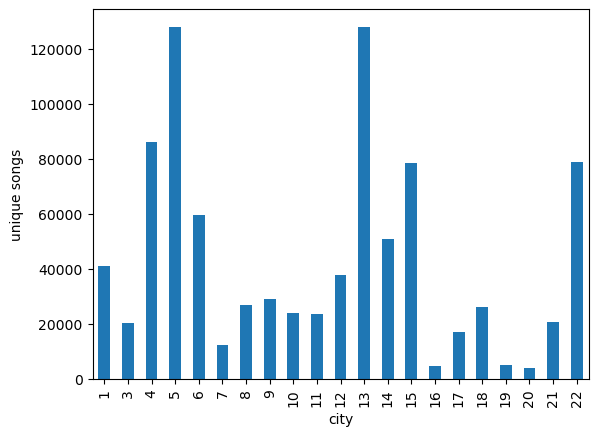

In [124]:
collab.groupby('city')['song_id'].value_counts()

city_songs = collab.groupby(['city', 'song_id'])['repeated'].sum().reset_index()
city_songs = city_songs.sort_values(['city', 'repeated'], ascending=[True, False])

# see top 5 songs per city
city_songs.groupby('city').head(5)

collab.groupby('city')['song_id'].nunique().plot(kind='bar')
plt.xlabel('city')
plt.ylabel('unique songs')
plt.savefig('city.png', dpi=300, bbox_inches='tight')
plt.show()

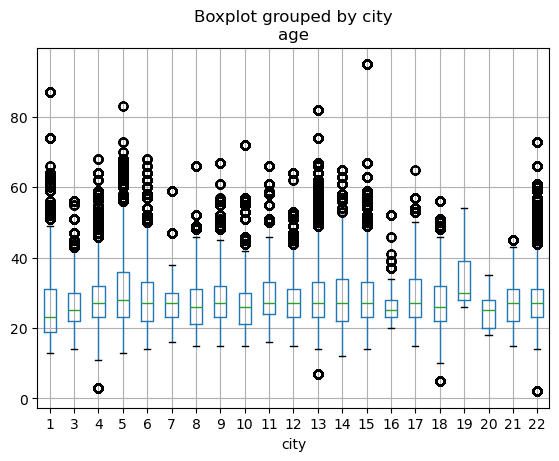

In [125]:
collab.boxplot(column='age', by='city')
plt.show()

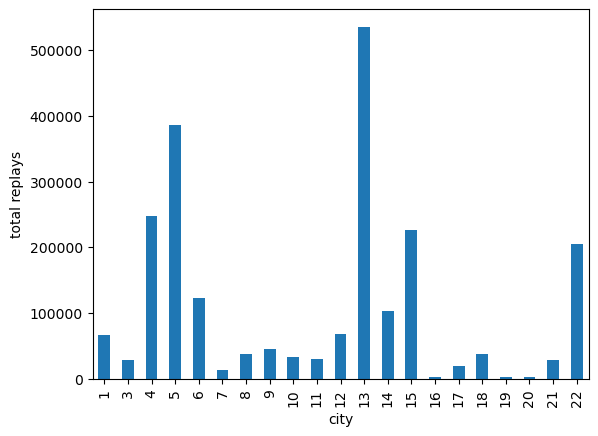

In [126]:
collab.groupby('city')['repeated'].sum().plot(kind='bar')
plt.ylabel('total replays')
plt.xlabel('city')
plt.show()

City 13 had the most replays and the most unique songs. City 5 had the second most unique songs, and city 15 and city 22 had a close number of unique songs (count). 

## Step 2:
- Data Visualization for content based filtering

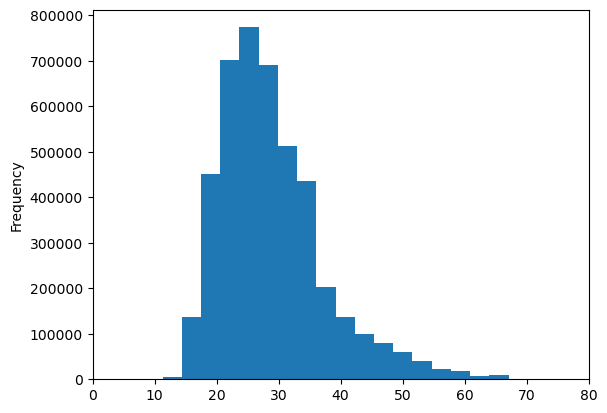

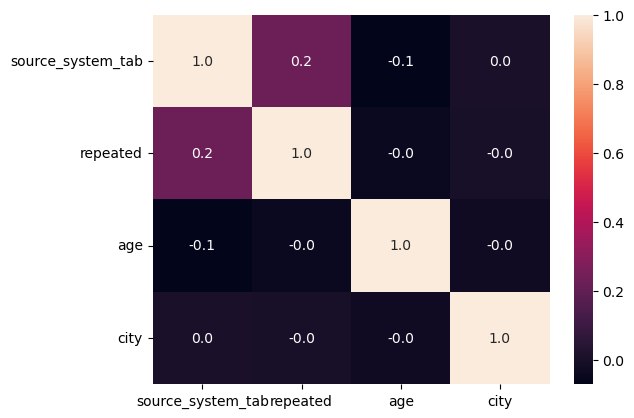

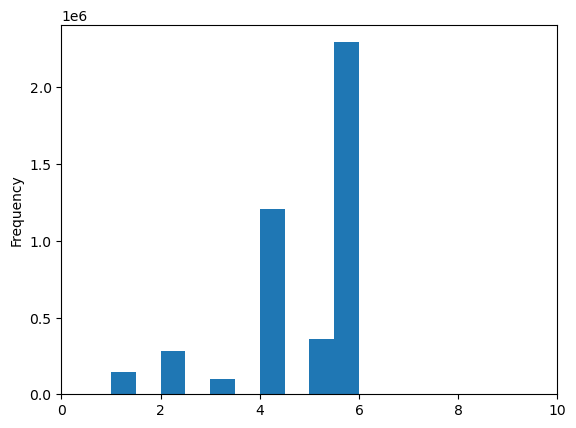

source_system_tab
6    2293821
4    1209209
5     362167
2     281797
1     147746
3      98153
Name: count, dtype: int64

In [133]:
import matplotlib.pyplot as plt
#age distribition
collab['age'].plot(kind='hist', bins=30) # visualize age distribution counts
plt.xlim(0, 80) # shorten the x axis so it's a clearer picture
plt.show()

# correlation heatmap
sns.heatmap(collab.corr(numeric_only=True), annot=True, fmt=".1f")
plt.show()

#frequency table for source system tabs
collab['source_system_tab'].plot(kind='hist', bins=10)
plt.xlim(0, 10)
plt.show()

collab['source_system_tab'].value_counts()

In [135]:
# check column names
df.columns

Index(['track_id', 'artists', 'album_name', 'track_name', 'popularity',
       'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness',
       'valence', 'tempo', 'time_signature', 'track_genre'],
      dtype='object')

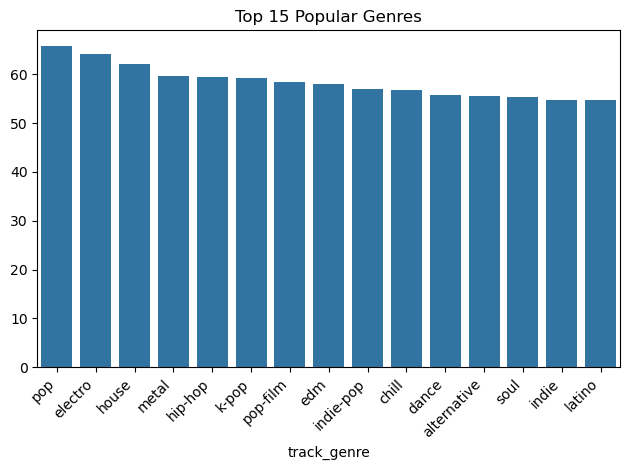

In [137]:
# bar plot of the first 15 most popular genres
plt.title("Top 15 Popular Genres")
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

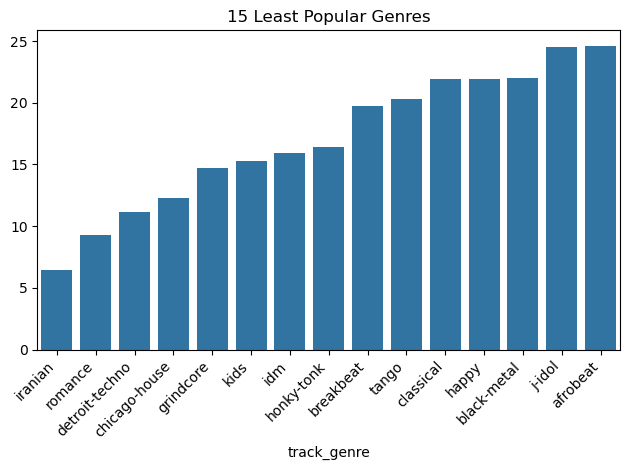

In [139]:
# plot for the 15 least popular genres
plt.title("15 Least Popular Genres")
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=True).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

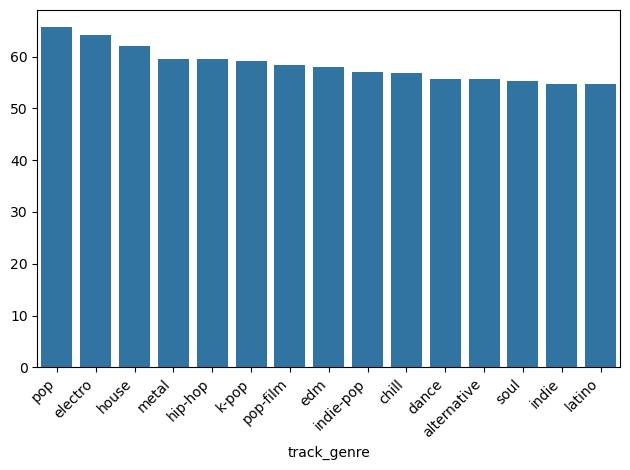

In [141]:
genre_pop = df.groupby("track_genre")["popularity"].mean().sort_values(ascending=False).head(15)
sns.barplot(x=genre_pop.index, y=genre_pop.values)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

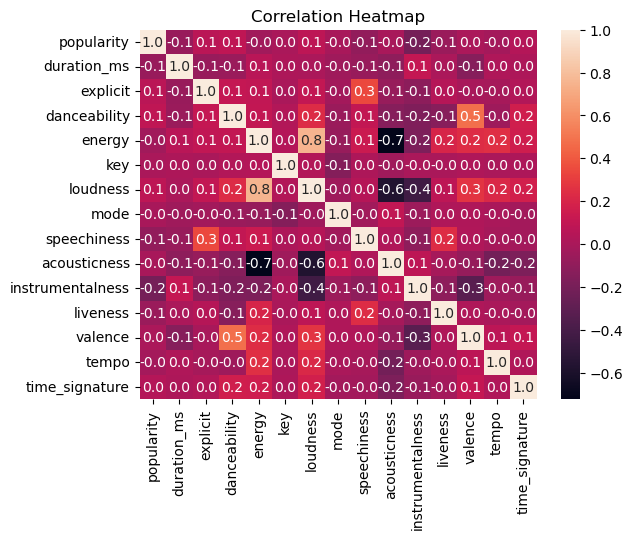

In [143]:
# heatmap plot correlating features
plt.title("Correlation Heatmap")
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".1f")
plt.show()

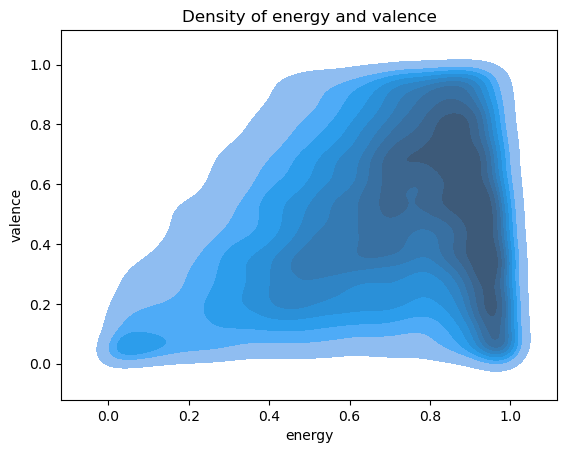

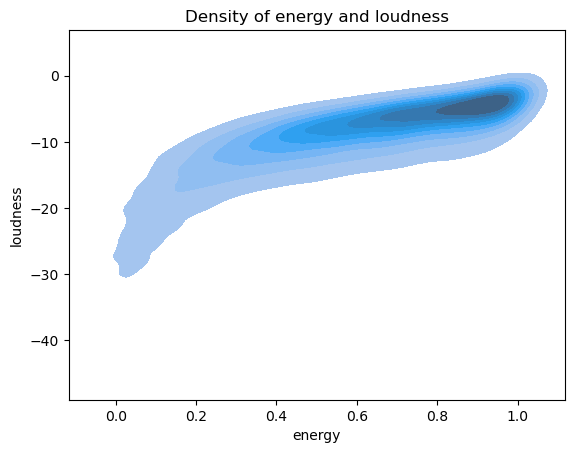

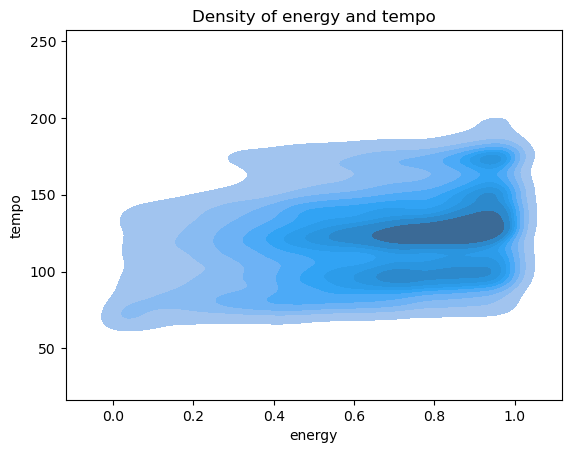

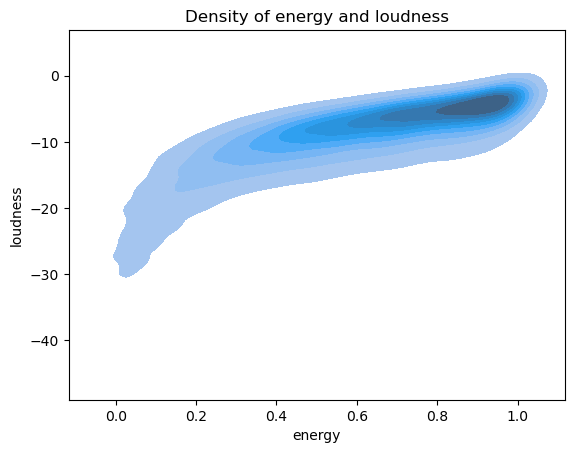

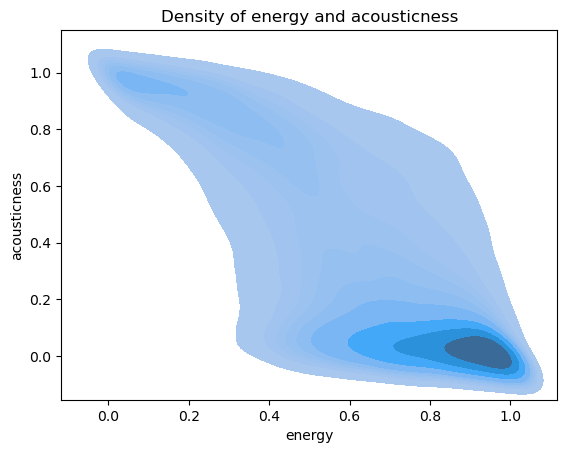

In [144]:
# 5 density plots comparing features with energy
# way to see how well songs can be correlated

features = ["valence","loudness","tempo","loudness", "acousticness"]

for f in features:
    sns.kdeplot(data=df,x="energy",y=f,fill=True,levels=10)
    plt.title(f"Density of energy and {f}")
    plt.show()

## Step 3: Collaborative Filtering
- We will now use NMF to find users' similarities with repeated songs

In [147]:
def train_test_split(df, test_size=0.2):
    """
    Function to randomly shuffle our data frame by each user  
    Split it into training and testing dataframes

    ARGS:
        df - user dataframe
        test_size - default 0.2. 20% of each user into testing 

    RETURNS: split dataframes
        train_df: the training dataframe (1-test_size) %
        test_df: testing dataframe  (test_size) %
    """

    train_rows = []
    test_rows = []

    # splitting based on user so that there is TEST_SIZE % in testing of each user
    for user, user_df in df.groupby('user_idx'):

        # shuffle user df so that we can have random train/testing 
        user_df = user_df.sample(frac=1, random_state=42)

        n_test = max(1, int(len(user_df) * test_size))
        test = user_df.iloc[:n_test]
        train = user_df.iloc[n_test:]

        train_rows.append(train)
        test_rows.append(test)

    # make into pandas df
    train_df = pd.concat(train_rows)
    test_df = pd.concat(test_rows)

    return train_df, test_df

In [148]:
# create matrix for Nonnegative matrix factorization
# rows are user, columns are song, filled with 1 if they repeated a song and 0 otherwise


# randomly sample the data so that we can debug easily 20% of the data
sample_users = collab['user'].drop_duplicates().sample(frac=0.2, random_state=42)
practice = collab[collab['user'].isin(sample_users)].copy()


# label encode the users and songs to build the sparse matrix
user_encoder = LabelEncoder()
song_encoder = LabelEncoder()

practice['user_idx'] = user_encoder.fit_transform(practice['user'])
practice['name_idx'] = song_encoder.fit_transform(practice['name'])

train_df, test_df = train_test_split(practice)

# build the matrix
matrix = csr_matrix((train_df['repeated'], (train_df['user_idx'], train_df['name_idx'])))

# check the sizes + should match the matrix size
print("Amt of users:", len(user_encoder.classes_))
print("Amt of songs:", len(song_encoder.classes_))
print("Matrix size:", matrix.shape)

Amt of users: 2436
Amt of songs: 85640
Matrix size: (2436, 85640)


In [149]:
# Why we use NMF: 
# https://communities.sas.com/t5/SAS-Communities-Library/Non-negative-Matrix-Factorization-Part-1-Understanding-Its/ta-p/973592

# NMF model
nmf_model = NMF(n_components=20, init='nndsvd', random_state=42, max_iter=200)

# lower rank decomposed matricies
W = nmf_model.fit_transform(matrix) # user latent features
H = nmf_model.components_ # song latent features / weights

In [150]:
# function to print out top ten recommended songs
def recommend_user(user_idx, W, H, train_matrix, top_k=10):
    """
    Function to return K top recommended songs based on a user

    ARGS:
    user_idx: the user to recommend to
    W: user latent features
    H: song latent features
    train_matrix: the sparse matrix
    top_K: integer value of TOP K songs to return (default 10)

    RETURNS:
    top_song_indices: sorted songs by top K recommended
    """

    # predict scores based on user id
    scores = W[user_idx] @ H

    # REMOVE already seen songs
    seen_songs = train_matrix[user_idx].indices
    scores[seen_songs] = -np.inf

    # sort songs by most recommended
    top_song_indices = np.argsort(scores)[::-1][:top_k]

    return top_song_indices

In [151]:
def decode_songs(song_indices, song_encoder):
    """
    Function that decodes the label encoded songs

    ARGS:
    song_indecies: the label encoded songs
    spng_encoder: label encoding 

    RETURNS:
    the decoded songs
    """

    return song_encoder.inverse_transform(song_indices)

In [152]:
test_lookup = (test_df.groupby('user_idx')['name_idx'].apply(set).to_dict())
test_lookup

{0: {436,
  5562,
  6943,
  7919,
  9380,
  11732,
  12389,
  12450,
  12511,
  13615,
  15937,
  17505,
  18395,
  19878,
  20216,
  21551,
  21764,
  22657,
  24702,
  26289,
  31729,
  32769,
  34155,
  35061,
  35354,
  36043,
  38107,
  40327,
  40639,
  40650,
  51631,
  53112,
  59117,
  61527,
  62566,
  63668,
  64775,
  66226,
  72703},
 1: {2670,
  4365,
  5705,
  5892,
  7235,
  11771,
  13414,
  15443,
  15537,
  18338,
  18439,
  18563,
  21803,
  24817,
  25021,
  28389,
  31053,
  31624,
  32290,
  32295,
  32509,
  37959,
  39043,
  39538,
  44340,
  47781,
  48430,
  50326,
  53677,
  54558,
  54668,
  54898,
  55033,
  55101,
  55539,
  55929,
  56142,
  56228,
  56903,
  57830,
  58211,
  58547,
  58905,
  59161,
  59665,
  60467,
  61453,
  61928,
  61945,
  62120,
  62472,
  63345,
  63608,
  64259,
  64751,
  65014,
  65594,
  65736,
  65938,
  66426,
  66686,
  66688,
  67961,
  68073,
  68536,
  68913,
  69691,
  70258,
  71268,
  71421,
  71630,
  73145,
  735

In [197]:
def at_k(W, H, train_matrix, test_lookup, k=10):
    """
    https://www.evidentlyai.com/ranking-metrics/precision-recall-at-k
    Function to return the Precision@K which is how relevant the top K recommended songs are and Recall@K which is how many of the 
    recommended songs are relevant are in the top K  

    ARGS:
    W: user latent features
    H: song latent features
    train_matrix: sparse matrix
    test_lookup: dictionary of grouped testing data to compare for relevance
    k: top K songs that we compare

    RETURNS:
    Precision@K, Recall@K value
    """

    precisions = []
    recall = []

    # looks at the relevance for each user then averages it out
    for user_idx in test_lookup.keys():

        # the top k recommendations for each user
        recommended = recommend_user(user_idx,W,H,matrix,top_k=k)
        
        # all the songs that a user listened to
        listened = test_lookup[user_idx]

        # relevance is def as overlap between how many are listened to from the top k recommendations
        relevant = len(set(recommended) & listened)

        # precision = number of relevant items in K / total number of items in K
        precisions.append(relevant / k)

        # recall = number of relevant items in K / total number of relevant items
        if len(listened) > 0:
            recall.append(relevant / len(listened))

    return np.mean(precisions), np.mean(recall)

In [213]:
top_k = [2, 4, 6, 8, 10, 12]
precision_scores = []
recall_scores = []

# see the relationship between precision and recall at different k values
for k in top_k:
    
    precision, recall = at_k(W,H,matrix,test_lookup,k=k)
    print(f"Precision@{k}:", precision)
    print(f"Recall@{k}:", recall)
    print()
    precision_scores.append(precision)
    recall_scores.append(recall)


Precision@2: 0.46551724137931033
Recall@2: 0.02082417566771635

Precision@4: 0.423747947454844
Recall@4: 0.036561199677821184

Precision@6: 0.3926518883415435
Recall@6: 0.04929364694695079

Precision@8: 0.36873973727422005
Recall@8: 0.059669158739727224

Precision@10: 0.3507389162561576
Recall@10: 0.06941873414713731

Precision@12: 0.3360016420361248
Recall@12: 0.07810156889965308



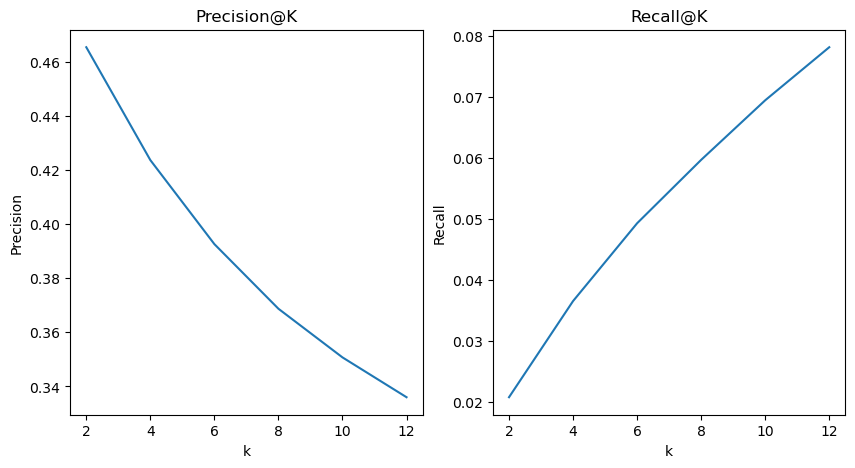

In [211]:
# plotting precision vs recall @ different k values
fig, ax = plt.subplots(1,2,figsize=(10,5))


ax[0].plot(top_k, precision_scores, label = f"Precision@k = {k}")
ax[1].plot(top_k, recall_scores, label = f"Recall@k = {k}")

ax[0].set_xlabel("k")
ax[0].set_ylabel("Precision")
ax[0].set_title("Precision@K")
ax[1].set_xlabel("k")
ax[1].set_ylabel("Recall")
ax[1].set_title("Recall@K")

plt.show()

In [ ]:
usercount = len(user_encoder.classes_)
# list 10 random users
users = random.sample(range(usercount), 10)

for user in users:
    recommended_indices = recommend_user(user,W,H, matrix,top_k=10)
    recommended_songs = decode_songs(recommended_indices,song_encoder)
    print(f"User #{user}")
    print(recommended_songs)
    print()